In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('superstore_cleaned.csv')

# Convert Order Date to datetime format so we can plot time trends later
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Display the first few rows to check it loaded correctly
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


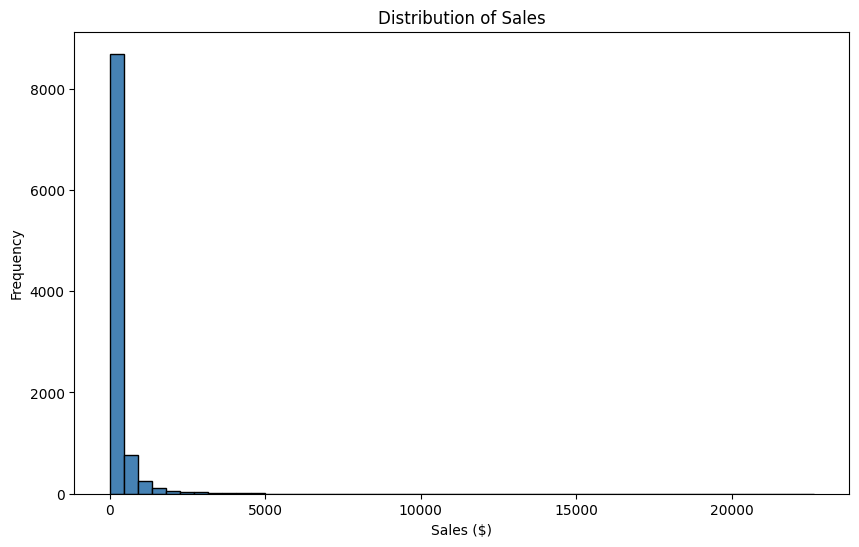

In [2]:
plt.figure(figsize=(10, 6))
plt.hist(df['Sales'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Sales')
plt.xlabel('Sales ($)')
plt.ylabel('Frequency')
plt.show()

The Sales distribution is right-skewed. This means most orders are for small amounts, but there are a few very large orders that create a long tail on the right side. It is not a normal bell curve.

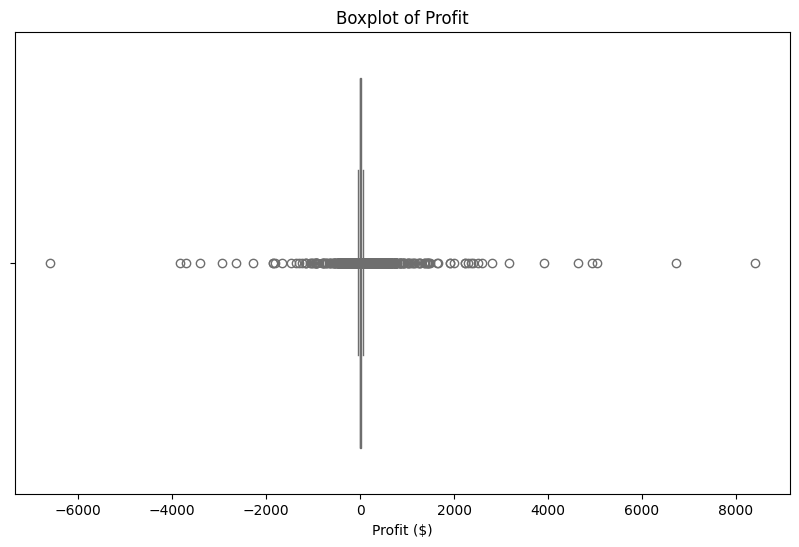

In [3]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Profit'], color='lightcoral')
plt.title('Boxplot of Profit')
plt.xlabel('Profit ($)')
plt.show()

The boxplot shows the median profit is close to zero. There are many outliers visible on both ends: some orders have very high profits, while others have significant losses (negative profit).

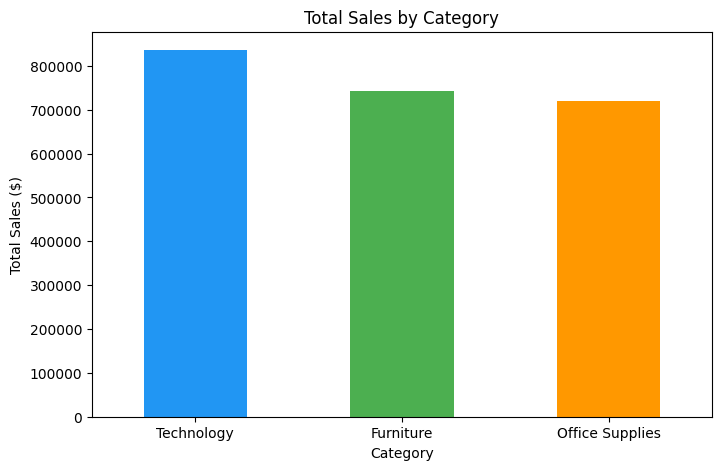

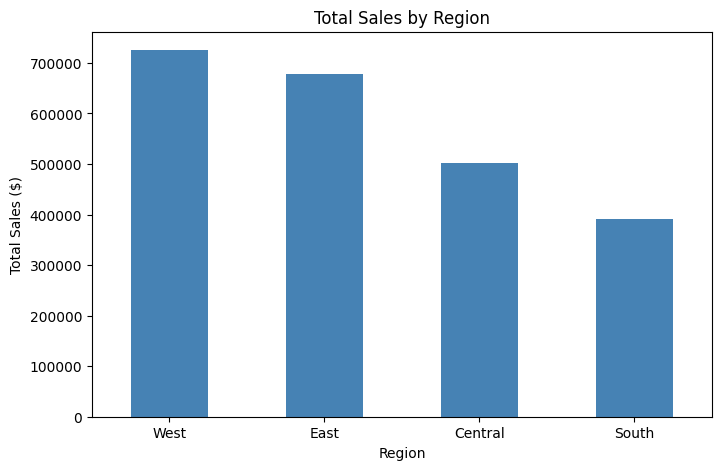

In [9]:
# Calculate total sales per category
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

# Plot
plt.figure(figsize=(8, 5))
cat_sales.plot(kind='bar', color=['#2196F3','#4CAF50','#FF9800'])
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.show()
# Calculate total sales per region
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

# Plot
plt.figure(figsize=(8, 5))
region_sales.plot(kind='bar', color='steelblue')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.show()

Technology generates the most revenue, followed by Furniture. The West region has the highest total sales. This is expected because technology items are often more expensive, and the West region has a large customer base.

In [6]:
# Calculate Q1, Q3, and IQR
Q1 = df['Profit'].quantile(0.25)
Q3 = df['Profit'].quantile(0.75)
IQR = Q3 - Q1

# Define boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find outliers
outliers = df[(df['Profit'] < lower_bound) | (df['Profit'] > upper_bound)]

# Print results
print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
print(f"Number of outliers: {len(outliers)}")

Q1: 1.73, Q3: 29.36, IQR: 27.64
Lower Bound: -39.72, Upper Bound: 70.82
Number of outliers: 1881


I found 1881 outliers. These are mixed: many are high-loss items (likely due to heavy discounts) and some are high-profit items. They represent extreme cases in the business.


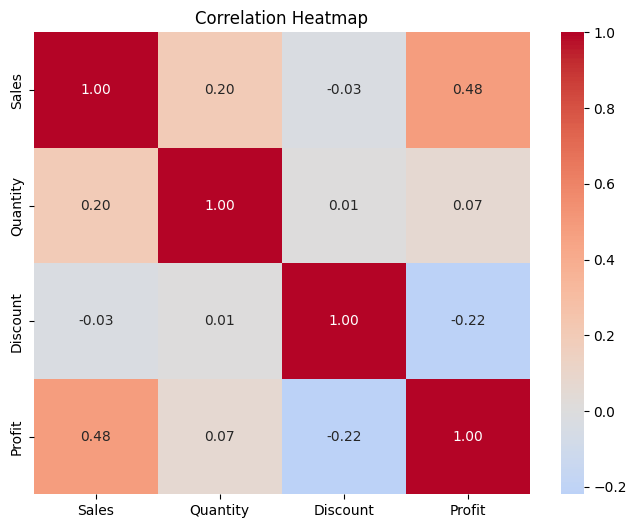

In [7]:
# Select numerical columns
numerical_cols = df[['Sales','Quantity','Discount','Profit']]
corr_matrix = numerical_cols.corr()

# Plot Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

Sales and Quantity have the strongest positive correlation. Discount and Profit have a negative correlation, which means that when discounts go up, profit usually goes down. This makes sense because discounts reduce the money made on each sale.


/tmp/ipykernel_1630/1426104491.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample('M', on='Order Date')['Sales'].sum()


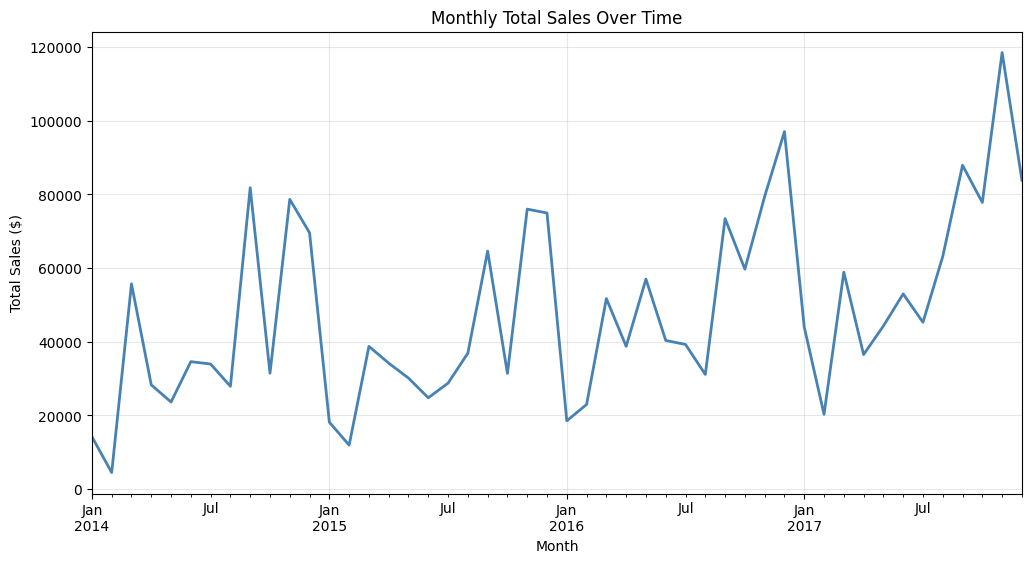

In [8]:
# Resample data to monthly totals
monthly_sales = df.resample('M', on='Order Date')['Sales'].sum()

# Plot Line Chart
plt.figure(figsize=(12, 6))
monthly_sales.plot(color='steelblue', linewidth=2)
plt.title('Monthly Total Sales Over Time')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.grid(True, alpha=0.3)
plt.show()

There is a clear seasonal pattern. Sales spike significantly in November and December, likely due to holiday shopping (like Christmas). There are often dips in the summer months or January, indicating slower retail periods.


1.Why is the Sales histogram right-skewed?

---


In retail, most customers buy small, cheap items frequently. Only a few customers buy very expensive items or large quantities. This creates a long "tail" of high values on the right side of the graph.

2.Should you remove Profit outliers?


---


No. Outliers often tell an important story, like a massive loss from a mistake or a huge win from a key client. If you remove them, you might miss critical risks or opportunities that need attention.

3.Should the company stop discounts if they correlate with lower profit?


---


Not necessarily. Discounts lower profit per item, but they might increase the total number of items sold. The company should check if the extra sales volume makes up for the lower profit margin before stopping discounts.

4.What action would you take as a store manager based on the trend?


---


Since sales spike in November and December, I would hire extra staff and stock more inventory during those months to handle the rush. During slow months (like January), I would run promotions to try to boost sales.